# 07 — Optimizers and the Complete End-to-End Training Loop (TensorFlow / Keras)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Training is repeated parameter estimation: sample a mini-batch, forward propagate, compute loss, backpropagate gradients, convert gradients into an optimizer update, then validate after the epoch. **Gradient is not the same thing as update.** SGD uses the current gradient directly; Momentum smooths updates with velocity; Adam combines moving averages of first and second moments.

The test split is deliberately absent from model-selection decisions in this notebook.


## Code walkthrough — complete TensorFlow / Keras training pipeline
This is the core executable training code. Read it line by line. The training path shuffles mini-batches and updates parameters; the validation path performs forward-only evaluation. Metrics are collected every epoch and the trained artifact is persisted for later inference notebooks.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


@tf.keras.utils.register_keras_serializable()
class MNISTMLP(tf.keras.Model):

    def __init__(self, hidden=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden = hidden
        self.fc1 = tf.keras.layers.Dense(
            hidden, activation=None, kernel_initializer="he_normal"
        )
        self.act = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(
            10, activation=None, kernel_initializer="glorot_uniform"
        )

    def call(self, x, training=False):
        z1 = self.fc1(x)
        a1 = self.act(z1)
        logits = self.fc2(a1)
        return logits


model = MNISTMLP(hidden=64)
_ = model(tf.zeros((1, 784), dtype=tf.float32))
X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(5000, seed=SEED)
    .batch(128)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(256)
    .prefetch(tf.data.AUTOTUNE)
)
model = MNISTMLP(hidden=64)
_ = model(tf.zeros((1, 784), dtype=tf.float32))
criterion = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


def run_epoch(dataset, training):
    total_loss = total_correct = total = 0.0
    for xb, yb in dataset:
        if training:
            with tf.GradientTape() as tape:
                logits = model(xb, training=True)
                loss = criterion(yb, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
        else:
            logits = model(xb, training=False)
            loss = criterion(yb, logits)
        batch_n = int(tf.shape(xb)[0])
        total_loss += float(loss) * batch_n
        total_correct += int(
            tf.reduce_sum(
                tf.cast(
                    tf.argmax(logits, 1, output_type=tf.int64) == tf.cast(yb, tf.int64),
                    tf.int32,
                )
            )
        )
        total += batch_n
    return (total_loss / total, total_correct / total)


history = []
for epoch in range(1, 6):
    train_loss, train_acc = run_epoch(train_ds, True)
    val_loss, val_acc = run_epoch(val_ds, False)
    history.append((train_loss, train_acc, val_loss, val_acc))
    print(
        f"epoch={epoch} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )
model.save(ARTIFACT_DIR / "mnist_tensorflow_mlp.keras")

2026-09-07 18:15:30.328639: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-07 18:15:33.744534: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-07 18:15:33.765460: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=1 train_loss=1.3376 train_acc=0.6394 val_loss=0.6966 val_acc=0.8340


2026-09-07 18:15:34.492429: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=2 train_loss=0.5621 train_acc=0.8594 val_loss=0.4723 val_acc=0.8650


epoch=3 train_loss=0.4301 train_acc=0.8866 val_loss=0.3995 val_acc=0.8840


2026-09-07 18:15:35.959370: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=4 train_loss=0.3686 train_acc=0.9028 val_loss=0.3610 val_acc=0.8960


epoch=5 train_loss=0.3309 train_acc=0.9124 val_loss=0.3413 val_acc=0.8960


## Code walkthrough — visualize optimization instead of reading only the final accuracy
Loss should generally decrease while validation accuracy improves. A widening train/validation gap is an overfitting signal. Flat loss can indicate poor learning rate, bad initialization, insufficient capacity, preprocessing bugs or gradient problems.


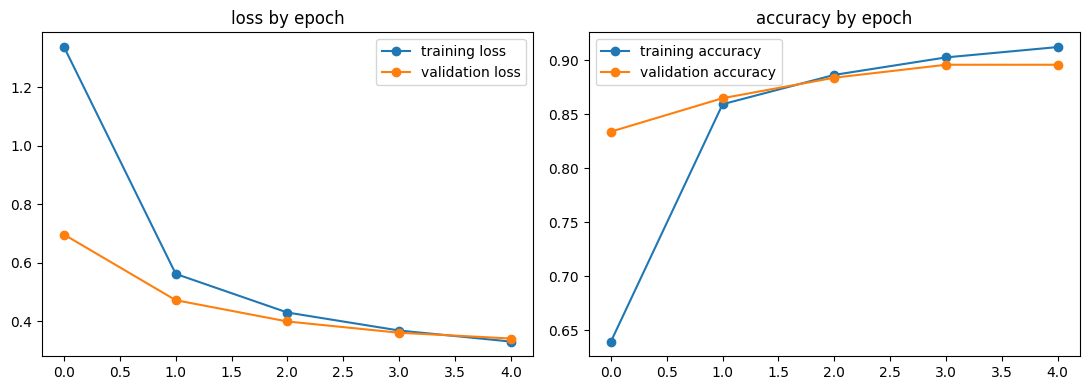

In [2]:
hist = np.asarray(history, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist[:, 0], marker="o", label="training loss")
if hist.shape[1] == 4:
    axes[0].plot(hist[:, 2], marker="o", label="validation loss")
axes[0].legend()
axes[0].set_title("loss by epoch")
axes[1].plot(hist[:, 1], marker="o", label="training accuracy")
axes[1].plot(hist[:, -1], marker="o", label="validation accuracy")
axes[1].legend()
axes[1].set_title("accuracy by epoch")
plt.tight_layout()
plt.show()

## Production engineering checklist
A production training job also records code commit, dataset version, split IDs, hyperparameters, seed, environment lock, metrics, artifact checksum and run timestamp. The notebook teaches the mechanics; an MLOps system automates provenance and promotion.
